# FX Pairs: Position-Level Risk Controls

**Chapter 19 - Risk Management**

A 20-day time exit improves the selected allocation's point estimates, but not the strength of
the evidence. Validation Sharpe rises from 0.037 to 0.048 and maximum drawdown falls from 29.7%
to 16.7%; the overlay's 95% Sharpe interval still spans zero. Tighter stops generally add trades
and reduce Sharpe, which matters because FX15 places the point-estimate breakeven at only 7.91 bps
per traded leg.

1. **Reproduction contract** - analyze the frozen registry without writing by default
2. **Risk sweep** - optionally apply the declared position controls to the selected lineage
3. **Risk evidence** - compare Sharpe uncertainty, drawdown, and trade count with no overlay

**Book Reference:** Chapter 19, Sections 19.3-19.6

**Prerequisites:** Completed Ch17 allocation results in `registry.db`.

In [1]:
"""Ch19 position-level risk controls for the FX pairs case study."""

import json
import sqlite3
import time
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices_for,
    warmup_periods_for,
)
from case_studies.utils.backtest_presets import (
    clone_backtest_spec,
    ensure_backtest_spec,
    serializable_backtest_spec,
    strategy_view,
)
from case_studies.utils.backtest_runner import (
    normalize_prediction_columns,
    precompute_weights,
    run_backtest,
)
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    load_existing_backtest_hashes,
    read_predictions,
    resolve_best_backtest_runs,
)
from case_studies.utils.sweep_config import (
    get_portfolio_risk_controls,
    get_position_risk_controls,
    get_top_n_predictions,
)
from utils.paths import get_case_study_dir
from utils.style import COLORS

In [2]:
CASE_STUDY_ID = "fx_pairs"
LABEL = "fwd_ret_21d"
SPLIT = "validation"
MAX_SYMBOLS = 0
MAX_RISK_VARIANTS = 0
TOP_N_COMBOS = None
RUN_SWEEP = False
FORCE_REBACKTEST = False

## 1. The default path is read-only

Risk controls sit on the same 21-day Ridge/HRP top-5 allocation evaluated in FX14 and FX15.
Validation ends before the sealed 2024 holdout, and the configured 7 bps per-leg friction remains
active in every stored overlay.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
REGISTRY_PATH = CASE_DIR / "run_log" / "registry.db"
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_COMBOS is None:
    TOP_N_COMBOS = get_top_n_predictions(CASE_STUDY_ID, "risk_overlay")

print(f"""=== Protocol Term Sheet ===
  Case study:    {CASE_STUDY_ID}
  Label:         {LABEL}
  Split:         {SPLIT}
  Calendar:      {bt_config.calendar}
  Cadence:       {bt_config.cadence}
  Execution:     {bt_config.execution_delay}
  Cost:          {bt_config.commission_bps + bt_config.slippage_bps:.1f} bps per leg
  Registry mode: {"write enabled" if RUN_SWEEP else "read only"}
""")

=== Protocol Term Sheet ===
  Case study:    fx_pairs
  Label:         fwd_ret_21d
  Split:         validation
  Calendar:      FX
  Cadence:       daily_ny_close
  Execution:     next_bar_open
  Cost:          7.0 bps per leg
  Registry mode: read only



In [4]:
top_combos = resolve_best_backtest_runs(
    CASE_STUDY_ID,
    LABEL,
    split=SPLIT,
    stage="allocation",
    top_n=TOP_N_COMBOS,
)
if top_combos.is_empty():
    raise RuntimeError("No validation allocation result found for the 21-day label")

for row in top_combos.iter_rows(named=True):
    allocation = strategy_view(json.loads(row["spec_json"]))["allocation"]
    print(
        f"Selected allocation: {allocation['method']} top-{allocation['top_k']} "
        f"Sharpe={row['sharpe']:.3f} hash={row['backtest_hash']}"
    )

Selected allocation: hrp top-5 Sharpe=0.037 hash=e1ac43ef7f7a


In [5]:
prices = load_backtest_prices_for(
    CASE_STUDY_ID,
    LABEL,
    split=SPLIT,
    warmup_periods=warmup_periods_for(CASE_STUDY_ID),
    max_symbols=MAX_SYMBOLS,
)
validation_end = prices["timestamp"].max()
if isinstance(validation_end, datetime):
    validation_end = validation_end.date()
holdout_start = datetime.fromisoformat(bt_config.holdout_start).date()
assert validation_end < holdout_start
print(f"Prices: {len(prices):,} rows, {prices['symbol'].n_unique()} pairs")
print(f"Validation ends {validation_end}; sealed holdout starts {holdout_start}")

Prices: 42,580 rows, 20 pairs
Validation ends 2023-12-29; sealed holdout starts 2024-01-01


## 2. The optional sweep changes only the position rule

The eligible grid contains only thresholds declared before evaluation. Predictions, top-5
selection, HRP weights, execution timing, and costs remain fixed. Thresholds calibrated on the
same validation window are ineligible because that would fit and evaluate a risk rule on the same
observations. Portfolio-level circuit breakers are deliberately absent because they are
governance controls rather than comparable position rules.

In [6]:
position_controls = get_position_risk_controls(CASE_STUDY_ID)
portfolio_controls = get_portfolio_risk_controls(CASE_STUDY_ID)
assert not portfolio_controls

if MAX_RISK_VARIANTS > 0:
    position_controls = position_controls[:MAX_RISK_VARIANTS]
print(f"Position controls: {len(position_controls)}; portfolio controls: 0")

Position controls: 14; portfolio controls: 0


In [7]:
def _risk_payload(control: dict) -> dict:
    if control["type"] == "time_exit":
        rule = {"type": control["type"], "bars": control["bars"]}
    else:
        rule = {"type": control["type"], "threshold": control["threshold"]}
    return {"name": control["name"], "position_rules": [rule]}


def _build_sweep_jobs() -> list[dict]:
    jobs = []
    for combo in top_combos.iter_rows(named=True):
        prediction_hash = combo["prediction_hash"]
        base_spec = ensure_backtest_spec(
            CASE_STUDY_ID,
            bt_config,
            json.loads(combo["spec_json"]),
            prices=prices,
            prediction_hash=prediction_hash,
            initial_cash=bt_config.initial_cash,
        )
        for control in position_controls:
            spec = clone_backtest_spec(base_spec)
            spec["chapter"] = "ch19"
            spec["strategy"]["risk"] = _risk_payload(control)
            jobs.append(
                {
                    "prediction_hash": prediction_hash,
                    "risk_name": control["name"],
                    "spec": spec,
                    "hash": backtest_hash_from_parts(
                        prediction_hash, serializable_backtest_spec(spec)
                    ),
                }
            )
    return jobs


sweep_jobs = _build_sweep_jobs()
print(f"Risk grid: {len(sweep_jobs)} backtests")

Risk grid: 14 backtests


In [8]:
existing_hashes = load_existing_backtest_hashes(CASE_STUDY_ID, stage="risk_overlay")
expected_hashes = {job["hash"] for job in sweep_jobs}
portable_overlap = expected_hashes & existing_hashes
print(f"Stored risk-overlay hashes: {len(existing_hashes)}")
print(f"Current-grid portable-hash overlap: {len(portable_overlap)}/{len(expected_hashes)}")

if RUN_SWEEP and existing_hashes and not portable_overlap:
    raise RuntimeError(
        "RUN_SWEEP refused: this registry uses legacy hashes. Migrate it or use a fresh registry."
    )
if not RUN_SWEEP:
    print("Reproduce-only mode: no backtests or registry rows will be written.")

Stored risk-overlay hashes: 59
Current-grid portable-hash overlap: 0/14
Reproduce-only mode: no backtests or registry rows will be written.


In [9]:
sweep_results = []
if RUN_SWEEP:
    pending = [job for job in sweep_jobs if FORCE_REBACKTEST or job["hash"] not in existing_hashes]
    prediction_hash = top_combos["prediction_hash"][0]
    predictions = normalize_prediction_columns(read_predictions(CASE_STUDY_ID, prediction_hash))
    base_spec = json.loads(top_combos["spec_json"][0])
    weights = precompute_weights(
        predictions,
        base_spec,
        prices,
        label=LABEL,
        case_study=CASE_STUDY_ID,
        prediction_hash=prediction_hash,
    )
    started = time.time()
    completed = failed = 0
    for job in pending:
        try:
            result = run_backtest(
                CASE_STUDY_ID,
                prediction_hash,
                job["spec"],
                prices=prices,
                predictions=predictions,
                label=LABEL,
                register=True,
                initial_cash=bt_config.initial_cash,
                calendar=bt_config.calendar,
                precomputed_weights=weights,
            )
            sweep_results.append(result)
            completed += 1
        except Exception as exc:
            failed += 1
            stamp = datetime.now(UTC).isoformat(timespec="seconds")
            print(f"[{stamp}] FAILED {job['hash']}: {type(exc).__name__}: {exc}")
        processed = completed + failed
        if processed % 5 == 0 or processed == len(pending):
            stamp = datetime.now(UTC).isoformat(timespec="seconds")
            print(f"[{stamp}] completed={completed} failed={failed} total={len(pending)}")
    print(f"Sweep elapsed: {time.time() - started:.1f}s")
    if failed:
        raise RuntimeError(f"Risk sweep finished with {failed} failed backtests")

## 3. A 20-day exit improves point estimates, not confidence

The immutable query below is pinned to the selected prediction. It cannot pool the one-day TCN or
five-day Ridge overlay panels into the 21-day result. The allocation row is the exact no-overlay
sibling, so point changes in Sharpe, drawdown, and trade count preserve the carrier and execution
protocol.

In [10]:
RISK_SQL = """
SELECT br.backtest_hash, br.spec_json,
       tr.family, tr.config_name, tr.label,
       bm.sharpe, bm.sharpe_ci95_lo, bm.sharpe_ci95_hi,
       bm.max_drawdown, bm.max_dd_ci95_lo, bm.max_dd_ci95_hi,
       bm.total_return, bm.num_trades, bm.avg_turnover
FROM backtest_runs br
JOIN backtest_metrics bm USING (backtest_hash)
JOIN prediction_sets ps USING (prediction_hash)
JOIN training_runs tr USING (training_hash)
WHERE br.stage = 'risk_overlay'
  AND ps.split = 'validation'
  AND br.prediction_hash = ?
ORDER BY bm.sharpe DESC
"""

BASELINE_SQL = """
SELECT br.backtest_hash, bm.sharpe, bm.sharpe_ci95_lo, bm.sharpe_ci95_hi,
       bm.max_drawdown, bm.max_dd_ci95_lo, bm.max_dd_ci95_hi,
       bm.total_return, bm.num_trades, bm.avg_turnover
FROM backtest_runs br
JOIN backtest_metrics bm USING (backtest_hash)
WHERE br.backtest_hash = ?
"""

In [11]:
def _read_registry(query: str, parameters: tuple = ()) -> pl.DataFrame:
    connection = sqlite3.connect(f"file:{REGISTRY_PATH}?mode=ro&immutable=1", uri=True)
    try:
        return pl.read_database(query, connection, execute_options={"parameters": parameters})
    finally:
        connection.close()


leader_prediction_hash = top_combos["prediction_hash"][0]
risk_rows = _read_registry(RISK_SQL, (leader_prediction_hash,))
baseline = _read_registry(BASELINE_SQL, (top_combos["backtest_hash"][0],))
if risk_rows.is_empty() or baseline.height != 1:
    raise RuntimeError("Stored 21-day risk overlay or its allocation baseline is missing")

risk_names = []
risk_types = []
risk_payloads = []
for spec_json in risk_rows["spec_json"]:
    risk = strategy_view(json.loads(spec_json))["risk"]
    risk_names.append(risk["name"])
    risk_types.append(risk["position_rules"][0]["type"])
    risk_payloads.append(json.dumps(risk, sort_keys=True, separators=(",", ":")))
risk_rows = risk_rows.with_columns(
    pl.Series("risk_name", risk_names),
    pl.Series("risk_type", risk_types),
    pl.Series("risk_payload", risk_payloads),
).drop("spec_json")

stored_names = set(risk_rows["risk_name"])
stored_payloads = set(risk_rows["risk_payload"])
declared_by_payload = {
    json.dumps(
        strategy_view(job["spec"])["risk"],
        sort_keys=True,
        separators=(",", ":"),
    ): job["risk_name"]
    for job in sweep_jobs
}
declared_payloads = set(declared_by_payload)
assert risk_rows.height == len(stored_names) == 20
eligible_payloads = stored_payloads & declared_payloads
missing_declared = declared_payloads - stored_payloads
historical_calibrated_names = set(
    risk_rows.filter(~pl.col("risk_payload").is_in(sorted(declared_payloads)))["risk_name"]
)
print(
    f"Frozen controls: {len(stored_names)} = {len(eligible_payloads)} declared + "
    f"{len(historical_calibrated_names)} historical calibrated"
)
if missing_declared:
    missing_names = sorted(declared_by_payload[payload] for payload in missing_declared)
    print(f"Declared controls absent from the frozen registry: {missing_names}")
print("Historical calibrated controls are audit-only and cannot win selection.")
print(
    risk_rows.select(
        "risk_name",
        "risk_type",
        "sharpe",
        "sharpe_ci95_lo",
        "sharpe_ci95_hi",
        "max_drawdown",
        "num_trades",
    )
)

Frozen controls: 20 = 14 declared + 6 historical calibrated
Historical calibrated controls are audit-only and cannot win selection.
shape: (20, 7)
┌──────────────┬──────────────┬───────────┬──────────────┬──────────────┬─────────────┬────────────┐
│ risk_name    ┆ risk_type    ┆ sharpe    ┆ sharpe_ci95_ ┆ sharpe_ci95_ ┆ max_drawdow ┆ num_trades │
│ ---          ┆ ---          ┆ ---       ┆ lo           ┆ hi           ┆ n           ┆ ---        │
│ str          ┆ str          ┆ f64       ┆ ---          ┆ ---          ┆ ---         ┆ f64        │
│              ┆              ┆           ┆ f64          ┆ f64          ┆ f64         ┆            │
╞══════════════╪══════════════╪═══════════╪══════════════╪══════════════╪═════════════╪════════════╡
│ time_exit_20 ┆ time_exit    ┆ 0.047624  ┆ -0.560212    ┆ 0.725714     ┆ -0.167337   ┆ 637.0      │
│ trailing_20p ┆ trailing_sto ┆ 0.029757  ┆ -0.64974     ┆ 0.774428     ┆ -0.298025   ┆ 503.0      │
│ ct           ┆ p            ┆           ┆  

In [12]:
base = baseline.row(0, named=True)
eligible_rows = risk_rows.filter(pl.col("risk_payload").is_in(sorted(declared_payloads)))
if eligible_rows.is_empty():
    raise RuntimeError("No frozen risk overlay matches a fully declared control payload")
leader = eligible_rows.row(0, named=True)
sharpe_delta = leader["sharpe"] - base["sharpe"]
drawdown_delta = leader["max_drawdown"] - base["max_drawdown"]
trade_delta = leader["num_trades"] - base["num_trades"]

print(f"Best overlay: {leader['risk_name']} ({leader['backtest_hash']})")
print(f"Sharpe: {base['sharpe']:.6f} -> {leader['sharpe']:.6f} (point delta {sharpe_delta:+.6f})")
print(
    f"Maximum drawdown: {base['max_drawdown']:.2%} -> {leader['max_drawdown']:.2%} "
    f"(point delta {drawdown_delta:+.2%})"
)
print(f"Trades: {base['num_trades']:.0f} -> {leader['num_trades']:.0f} ({trade_delta:+.0f})")
print("No exact baseline-versus-overlay paired metric is stored; point deltas are descriptive.")

Best overlay: time_exit_20 (4856002ebf10)
Sharpe: 0.037126 -> 0.047624 (point delta +0.010498)
Maximum drawdown: -29.65% -> -16.73% (point delta +12.92%)
Trades: 501 -> 637 (+136)
No exact baseline-versus-overlay paired metric is stored; point deltas are descriptive.


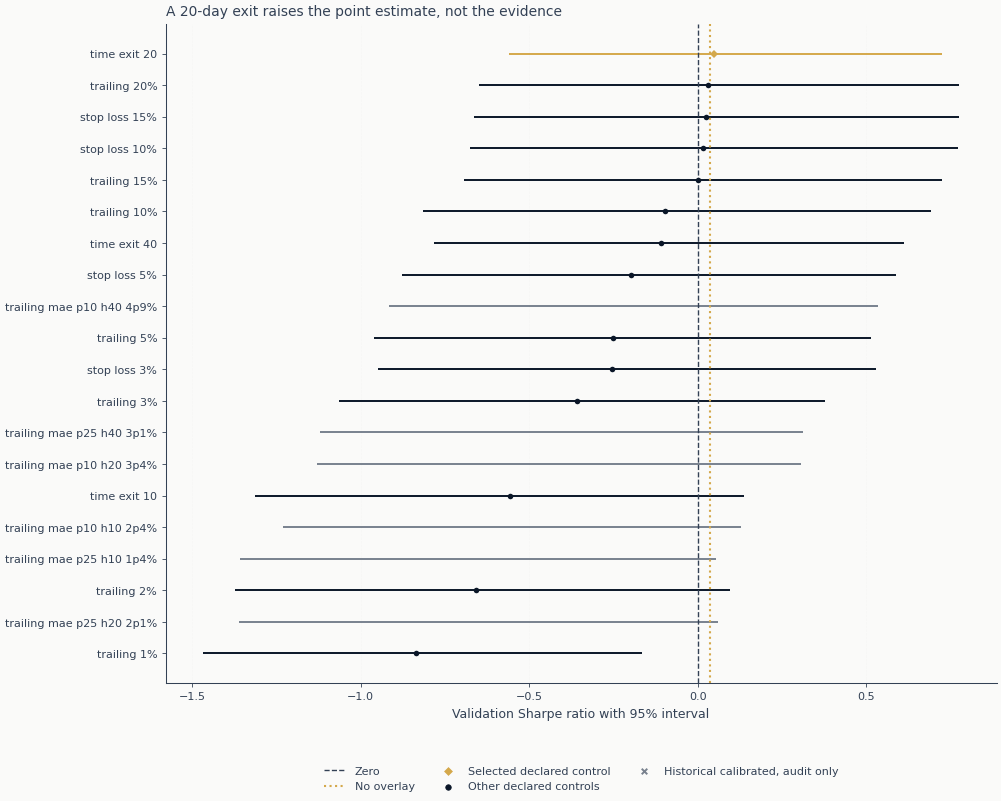

In [13]:
plot_rows = risk_rows.sort("sharpe")
y = np.arange(plot_rows.height)
points = plot_rows["sharpe"].to_numpy()
lower = plot_rows["sharpe_ci95_lo"].to_numpy()
upper = plot_rows["sharpe_ci95_hi"].to_numpy()
colors = [
    COLORS["amber"]
    if payload == leader["risk_payload"]
    else COLORS["blue"]
    if payload in declared_payloads
    else COLORS["neutral"]
    for payload in plot_rows["risk_payload"]
]
markers = [
    "D" if payload == leader["risk_payload"] else "o" if payload in declared_payloads else "x"
    for payload in plot_rows["risk_payload"]
]
alphas = [1.0 if payload in declared_payloads else 0.65 for payload in plot_rows["risk_payload"]]

fig, ax = plt.subplots(figsize=(10, 8))
for idx, (point, lo, hi, color, marker, alpha) in enumerate(
    zip(points, lower, upper, colors, markers, alphas, strict=True)
):
    ax.errorbar(
        point,
        idx,
        xerr=[[point - lo], [hi - point]],
        fmt=marker,
        color=color,
        ecolor=color,
        elinewidth=1.4,
        capsize=3,
        alpha=alpha,
    )
ax.axvline(0, color=COLORS["neutral"], linewidth=1, linestyle="--", label="Zero")
ax.axvline(
    base["sharpe"],
    color=COLORS["amber"],
    linewidth=1.5,
    linestyle=":",
    label="No overlay",
)
ax.scatter([], [], marker="D", color=COLORS["amber"], label="Selected declared control")
ax.scatter([], [], marker="o", color=COLORS["blue"], label="Other declared controls")
ax.scatter(
    [],
    [],
    marker="x",
    color=COLORS["neutral"],
    alpha=0.65,
    label="Historical calibrated, audit only",
)
ax.set_yticks(y)
ax.set_yticklabels([name.replace("pct", "%").replace("_", " ") for name in plot_rows["risk_name"]])
ax.set_xlabel("Validation Sharpe ratio with 95% interval")
ax.set_title("A 20-day exit raises the point estimate, not the evidence")
ax.grid(axis="x", alpha=0.22)
ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.11),
)
fig.show()

## Key takeaways

1. **The 20-day exit is the least-weak overlay.** It raises point Sharpe from `0.037126` to
   `0.047624`, but its interval `[-0.560212, 0.725714]` crosses zero.
2. **Drawdown improves at the point estimate.** Maximum drawdown moves from `-29.65%` without an
   overlay to `-16.73%` with the 20-day exit. The stored drawdown intervals overlap, so this is not
   evidence of a reliably smaller drawdown.
3. **The exit changes the trading path.** Registered trades rise from 501 to 637. With the cost
   point estimate crossing zero near 7.91 bps per leg, added execution remains a material concern.
4. **Tight trailing stops are destructive.** The 1% trailing stop falls to Sharpe `-0.835379`, and
   its 95% interval excludes zero on the negative side.
5. **Same-window calibration is ineligible.** Six historical thresholds were calibrated on the
   evaluation window and remain visible only for audit. The leader is the predeclared 20-day exit,
   so excluding those rows from selection does not change the result.

**Next:** The strategy-analysis notebook assembles the frozen stage, cohort, benchmark, and
holdout evidence into the final FX case-study assessment.